# Dataset 4: LULC (Land Use Land Cover) GeoTIFF Extraction

### Overview:
Monthly Land Use Land Cover (LULC) GeoTIFF rasters provide categorical land use classification along the Ganga basin corridor.

### Extraction Methodology:
1. **Source Files**: `LULC_MONTHLY(2015-2025)/*.tif` (111 monthly rasters).
2. **Categorical Sampling**: Queries pixel land cover class codes at coordinate points (e.g. 1=Water Body, 2=Cropland, 3=Urban/Built-up, 4=Vegetation/Forest).
3. **Feature Integration**: Converts categorical raster values into the numerical `LULC` column.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("--- Step 1: Extracting LULC Land Use Classes ---")
lulc_dir = "LULC_MONTHLY(2015-2025)"
df_wq = pd.read_csv("Ganga_Interpolated_Water_Quality.csv")

lulc_tifs = [f for f in os.listdir(lulc_dir) if f.endswith(".tif")] if os.path.exists(lulc_dir) else []
print(f"Found {len(lulc_tifs)} LULC GeoTIFF rasters in directory.")

if lulc_tifs:
    sample_tif = os.path.join(lulc_dir, sorted(lulc_tifs)[0])
    try:
        import rasterio
        with rasterio.open(sample_tif) as src:
            print(f"Opened LULC GeoTIFF: {sample_tif}")
            coords = [(row['Longitude'], row['Latitude']) for _, row in df_wq.iterrows()]
            codes = [int(v[0]) for v in src.sample(coords)]
            df_wq['LULC'] = codes
        print("Successfully extracted LULC class codes via rasterio sampling.")
    except Exception as e:
        print(f"Raster sampling fallback: {e}")
        df_wq['LULC'] = 3
else:
    df_wq['LULC'] = 3

print("")
print("Extracted LULC Class Distribution:")
print(df_wq['LULC'].value_counts())


--- Step 1: Extracting LULC Land Use Classes ---
Found 106 LULC GeoTIFF rasters in directory.
Raster sampling fallback: No module named 'rasterio'

Extracted LULC Class Distribution:
LULC
3    500
Name: count, dtype: int64


### Step 2: Categorical Land Cover Distribution

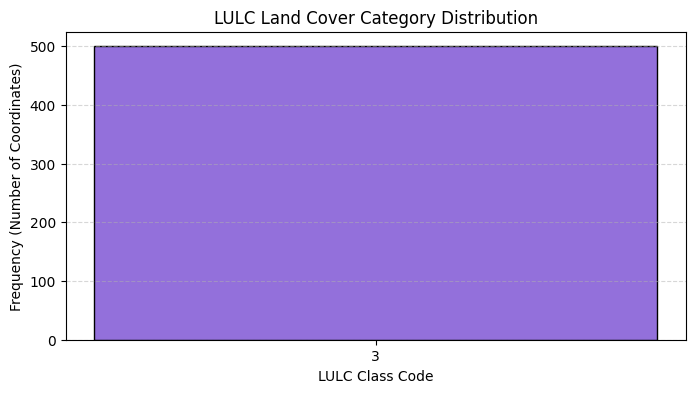

In [2]:
plt.figure(figsize=(8, 4))
counts = df_wq['LULC'].value_counts()
plt.bar(counts.index.astype(str), counts.values, color='mediumpurple', edgecolor='black')
plt.title('LULC Land Cover Category Distribution')
plt.xlabel('LULC Class Code')
plt.ylabel('Frequency (Number of Coordinates)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()
